In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [44]:
df = pd.read_csv(
    "prostat.tsv",
    sep="\t",
    dtype=str
)

print("Raw shape:", df.shape)

Raw shape: (505, 69)


In [45]:
df.head()

,#Other Patient ID,Patient Identifier,Form completion date,Neoplasm Histologic Type Name,Tumor Other Histologic Subtype,Patient Primary Tumor Site,Gleason pattern primary,Gleason pattern secondary,Radical Prostatectomy Gleason Score for Prostate Cancer,Gleason pattern tertiary,...,Race Category,Stage Other,American Joint Committee on Cancer Publication Version Type,Adjuvant Postoperative Targeted Therapy Administered Indicator,Tissue Source Site,Tumor Tissue Site,Overall Survival Status,Overall Survival (Months),Disease Free Status,Disease Free (Months)
0,#Legacy DMP patient identifier (DMPnnnn),Identifier to uniquely specify a patient.,Form completion date,Text term for the structural pattern of cancer...,Text to describe a tumor's histologic subtype ...,Text term to describe the organ sub-division i...,Gleason pattern primary,Gleason pattern secondary,The score derived from universally embraced pr...,Gleason pattern tertiary,...,The text for reporting information about race.,Stage Other,The version or edition of the American Joint C...,Text term to signify postoperative adjuvant ca...,"A Tissue Source Site collects samples (tissue,...",Text term that describes the anatomic site of ...,Overall patient survival status.,Overall survival in months since initial diago...,Disease free status since initial diagnosis.,Disease free (months) since initial diagnosis.
1,#STRING,STRING,STRING,STRING,STRING,STRING,NUMBER,NUMBER,STRING,NUMBER,...,STRING,STRING,STRING,STRING,STRING,STRING,STRING,NUMBER,STRING,NUMBER
2,#1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OTHER_PATIENT_ID,PATIENT_ID,FORM_COMPLETION_DATE,HISTOLOGICAL_DIAGNOSIS,HISTOLOGICAL_SUBTYPE,PRIMARY_SITE_PATIENT,GLEASON_PATTERN_PRIMARY,GLEASON_PATTERN_SECONDARY,GLEASON_SCORE,GLEASON_PATTERN_TERTIARY,...,RACE,STAGE_OTHER,AJCC_STAGING_EDITION,TARGETED_MOLECULAR_THERAPY,TISSUE_SOURCE_SITE,SITE_OF_TUMOR_TISSUE,OS_STATUS,OS_MONTHS,DFS_STATUS,DFS_MONTHS


In [46]:
df = df.iloc[5:].copy()

print("Shape after removing metadata:", df.shape)

Shape after removing metadata: (500, 69)


In [47]:
df = df.reset_index(drop=True)

print(df.shape)

(500, 69)


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 69 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   #Other Patient ID                                                                            500 non-null    object
 1   Patient Identifier                                                                           500 non-null    object
 2   Form completion date                                                                         500 non-null    object
 3   Neoplasm Histologic Type Name                                                                500 non-null    object
 4   Tumor Other Histologic Subtype                                                               500 non-null    object
 5   Patient Primary Tumor Site                 

In [49]:
df = df.replace(
    [
        "[Not Available]",
        "[Not Applicable]",
        "[Unknown]",
        "Unknown",
        ""
    ],
    np.nan
)

C:\Users\modernkade\AppData\Local\Temp\ipykernel_2412\221752083.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(


In [50]:
missing = df.isna().sum()

missing = missing[
    missing > 0
].sort_values(
    ascending=False
)

missing.head(20)

Neoplasm American Joint Committee on Cancer Clinical Group Stage                    500
Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage    500
Disease code                                                                        500
Lymphomatous Extranodal Site Involvement Indicator                                  500
American Joint Committee on Cancer Metastasis Stage Code                            500
Neoplasm Disease Stage American Joint Committee on Cancer Code                      500
American Joint Committee on Cancer Publication Version Type                         500
Stage Other                                                                         500
Project code                                                                        500
Patient Death Reason                                                                496
Cause of death source                                                               494
Tumor Other Histologic Subtype  

In [51]:
target = "Biochemical Recurrence Indicator"

print("Target:", target)

Target: Biochemical Recurrence Indicator


In [52]:
df[target].value_counts(
    dropna=False
)

Biochemical Recurrence Indicator
NO     373
NaN     69
YES     58
Name: count, dtype: int64

In [53]:
df = df.dropna(
    subset=[target]
).copy()

print("Shape:", df.shape)

Shape: (431, 69)


In [54]:
df[target] = df[target].map({
    "NO": 0,
    "YES": 1
})

df[target].value_counts()

Biochemical Recurrence Indicator
0    373
1     58
Name: count, dtype: int64

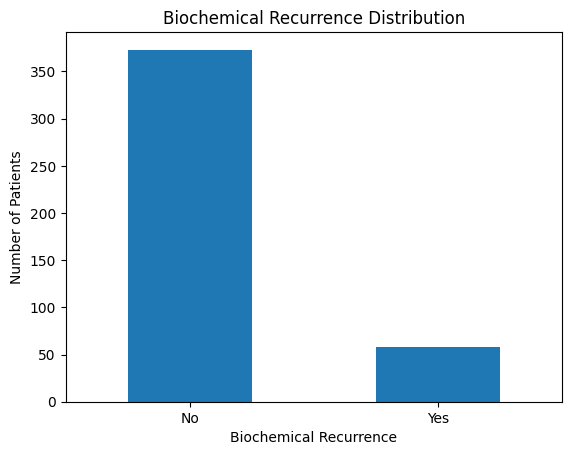

In [55]:
df[target].value_counts().sort_index().plot(
    kind="bar"
)

plt.title(
    "Biochemical Recurrence Distribution"
)

plt.xlabel(
    "Biochemical Recurrence"
)

plt.ylabel(
    "Number of Patients"
)

plt.xticks(
    [0, 1],
    ["No", "Yes"],
    rotation=0
)

plt.show()

In [56]:
identifier_columns = [
    "#Other Patient ID",
    "Patient Identifier"
]

identifier_columns = [
    column
    for column in identifier_columns
    if column in df.columns
]

df = df.drop(
    columns=identifier_columns
)

print(
    "Removed:",
    identifier_columns
)

Removed: ['#Other Patient ID', 'Patient Identifier']


In [57]:
leakage_columns = [
    "Days to biochemical recurrence first",
    "Disease Free Status",
    "Disease Free (Months)",
    "Overall Survival Status",
    "Overall Survival (Months)",
    "Patient Death Reason",
    "Cause of death source"
]

leakage_columns = [
    column
    for column in leakage_columns
    if column in df.columns
]

df = df.drop(
    columns=leakage_columns
)

print(
    "Removed leakage columns:"
)

print(leakage_columns)

Removed leakage columns:
['Days to biochemical recurrence first', 'Disease Free Status', 'Disease Free (Months)', 'Overall Survival Status', 'Overall Survival (Months)', 'Patient Death Reason', 'Cause of death source']


In [58]:
extra_columns = [
    "Tissue Source Site",
    "ICD-10 Classification",
    "International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code"
]


remove_extra = [
    c for c in extra_columns
    if c in df.columns
]


df = df.drop(
    columns=remove_extra
)


print(
    "Removed extra columns:"
)

print(remove_extra)

Removed extra columns:
['Tissue Source Site', 'ICD-10 Classification', 'International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code']


In [59]:
empty_columns = df.columns[
    df.isna().all()
].tolist()

print(
    "Completely empty columns:",
    len(empty_columns)
)

print(empty_columns)

Completely empty columns: 9
['Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage', 'Neoplasm American Joint Committee on Cancer Clinical Group Stage', 'Disease code', 'Lymphomatous Extranodal Site Involvement Indicator', 'American Joint Committee on Cancer Metastasis Stage Code', 'Neoplasm Disease Stage American Joint Committee on Cancer Code', 'Project code', 'Stage Other', 'American Joint Committee on Cancer Publication Version Type']


In [60]:
df = df.drop(
    columns=empty_columns
)

print(
    "Shape after removing empty columns:",
    df.shape
)

Shape after removing empty columns: (431, 48)


In [61]:
X = df.drop(
    columns=[target]
)

y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (431, 47)
y shape: (431,)


In [62]:
numeric_columns = [
    "Gleason pattern primary",
    "Gleason pattern secondary",
    "Gleason pattern tertiary",
    "Year Cancer Initial Diagnosis",
    "Days to bone Scan performed",
    "Days to mri",
    "Lymph Node(s) Examined Number",
    "Positive Finding Lymph Node Hematoxylin and Eosin Staining Microscopy Count",
    "Days to PSA",
    "Psa most recent results",
    "Diagnosis Age",
    "Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value"
]

for column in numeric_columns:
    if column in X.columns:
        X[column] = pd.to_numeric(
            X[column],
            errors="coerce"
        )

In [63]:
# حذف ستون‌های غیر مفید قبل از encoding

remove_columns = []

for col in X.columns:
    
    if "Form completion date" in col:
        remove_columns.append(col)
        
    if "Unnamed" in col:
        remove_columns.append(col)


print("Columns to remove:")
print(remove_columns[:10])
print("Total removed:", len(remove_columns))


X = X.drop(
    columns=remove_columns
)

print(
    "New shape:",
    X.shape
)

Columns to remove:
['Form completion date', 'Unnamed: 21']
Total removed: 2
New shape: (431, 45)


In [64]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print(
    "X shape after encoding:",
    X.shape
)

X shape after encoding: (431, 97)


In [65]:
# تبدیل True/False به 1/0
X = X.replace({
    True: 1,
    False: 0
})

# تبدیل همه ستون‌ها به عدد
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)

print(
    "Non-numeric columns:"
)

print(
    X.select_dtypes(
        exclude=["number"]
    ).columns.tolist()
)

Non-numeric columns:
[]


C:\Users\modernkade\AppData\Local\Temp\ipykernel_2412\3928658016.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace({


In [66]:
from sklearn.impute import SimpleImputer

# حذف ستون‌هایی که کاملاً خالی هستند
empty_columns = X.columns[
    X.isna().all()
]

print(
    "Removing empty columns:",
    len(empty_columns)
)

X = X.drop(
    columns=empty_columns
)


# پر کردن مقادیر خالی
imputer = SimpleImputer(
    strategy="median"
)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)


print(
    "NaN after imputation:",
    X.isna().sum().sum()
)

Removing empty columns: 0
NaN after imputation: 0


In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (344, 97)
Testing data: (87, 97)


In [ ]:
print(
    "Train NaN:",
    np.isnan(X_train).sum()
)

print(
    "Test NaN:",
    np.isnan(X_test).sum()
)

Train NaN: Gleason pattern primary                                               0
Gleason pattern secondary                                             0
Gleason pattern tertiary                                              0
Year Cancer Initial Diagnosis                                         0
Days to bone Scan performed                                           0
                                                                     ..
American Joint Committee on Cancer Tumor Stage Code_T4                0
American Joint Committee on Cancer Tumor Stage Code_[Discrepancy]     0
Race Category_BLACK OR AFRICAN AMERICAN                               0
Race Category_WHITE                                                   0
Adjuvant Postoperative Targeted Therapy Administered Indicator_YES    0
Length: 97, dtype: int64
Test NaN: Gleason pattern primary                                               0
Gleason pattern secondary                                             0
Gleason pattern te

In [69]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [70]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [71]:
logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [72]:
print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=[
            "No Recurrence",
            "Recurrence"
        ]
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test, logistic_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        logistic_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        logistic_pred,
        zero_division=0
    )

)

print(
    "F1 Score:",
    f1_score(
        y_test,
        logistic_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        logistic_prob
    )
)

               precision    recall  f1-score   support

No Recurrence       0.92      0.93      0.93        75
   Recurrence       0.55      0.50      0.52        12

     accuracy                           0.87        87
    macro avg       0.73      0.72      0.72        87
 weighted avg       0.87      0.87      0.87        87

Accuracy: 0.8735632183908046
Precision: 0.5454545454545454
Recall: 0.5
F1 Score: 0.5217391304347826
ROC-AUC: 0.8877777777777778


In [73]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [74]:
rf_pred = random_forest_model.predict(
    X_test
)

rf_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [75]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "No Recurrence",
            "Recurrence"
        ]
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test, rf_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        rf_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        rf_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        rf_pred,
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf_prob
    )
)

               precision    recall  f1-score   support

No Recurrence       0.91      1.00      0.96        75
   Recurrence       1.00      0.42      0.59        12

     accuracy                           0.92        87
    macro avg       0.96      0.71      0.77        87
 weighted avg       0.93      0.92      0.90        87

Accuracy: 0.9195402298850575
Precision: 1.0
Recall: 0.4166666666666667
F1 Score: 0.5882352941176471
ROC-AUC: 0.9888888888888889


In [76]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(
            y_test,
            logistic_pred,
            zero_division=0
        ),
        precision_score(
            y_test,
            rf_pred,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            logistic_pred,
            zero_division=0
        ),
        recall_score(
            y_test,
            rf_pred,
            zero_division=0
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            logistic_pred,
            zero_division=0
        ),
        f1_score(
            y_test,
            rf_pred,
            zero_division=0
        )
    ],

    "ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_prob
        ),
        roc_auc_score(
            y_test,
            rf_prob
        )
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.873563,0.545455,0.500000,0.521739,0.887778
1,Random Forest,0.919540,1.000000,0.416667,0.588235,0.988889


[[70  5]
 [ 6  6]]


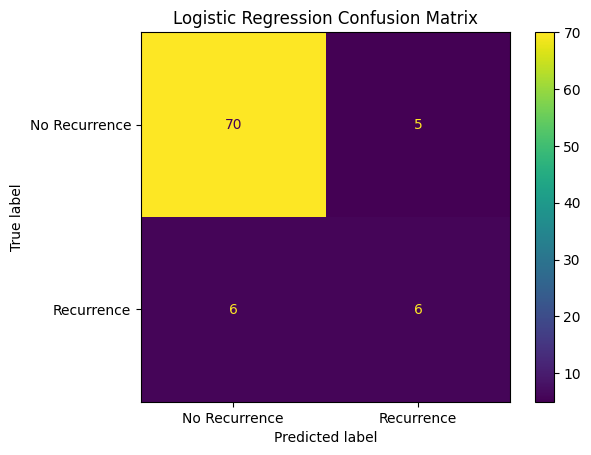

In [77]:
cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

print(cm_logistic)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "No Recurrence",
        "Recurrence"
    ]
).plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

[[75  0]
 [ 7  5]]


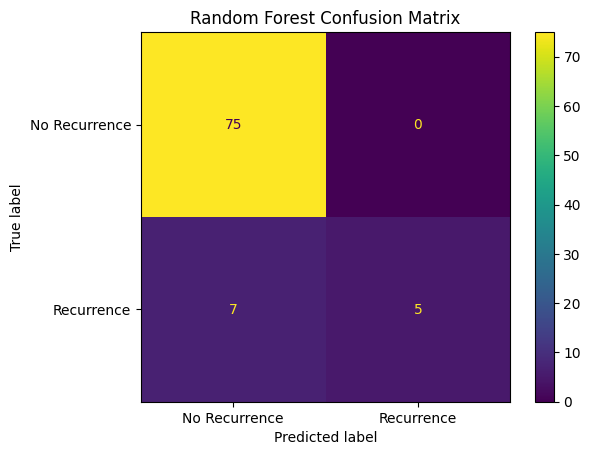

In [78]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

print(cm_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "No Recurrence",
        "Recurrence"
    ]
).plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

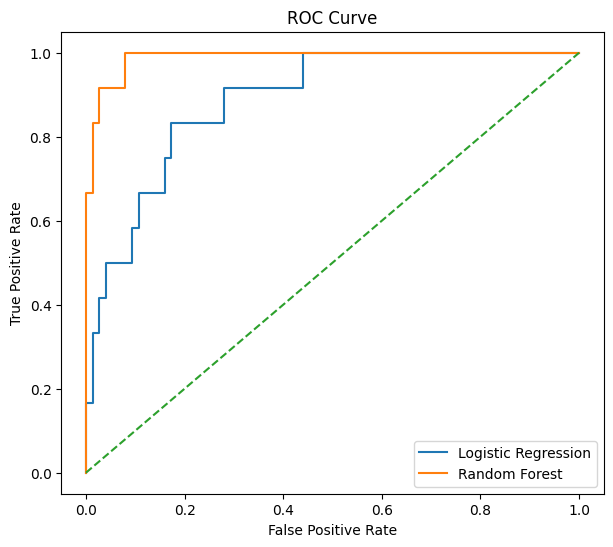

In [79]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.show()

In [80]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,Psa most recent results,0.203231
73,New Neoplasm Event Post Initial Therapy Indica...,0.150316
66,Person Neoplasm Status_WITH TUMOR,0.060409
8,Days to PSA,0.059685
6,Lymph Node(s) Examined Number,0.037496
10,Diagnosis Age,0.035255
3,Year Cancer Initial Diagnosis,0.032499
4,Days to bone Scan performed,0.032167
7,Positive Finding Lymph Node Hematoxylin and Eo...,0.019274
69,Primary Therapy Outcome Success Type_Partial R...,0.017942


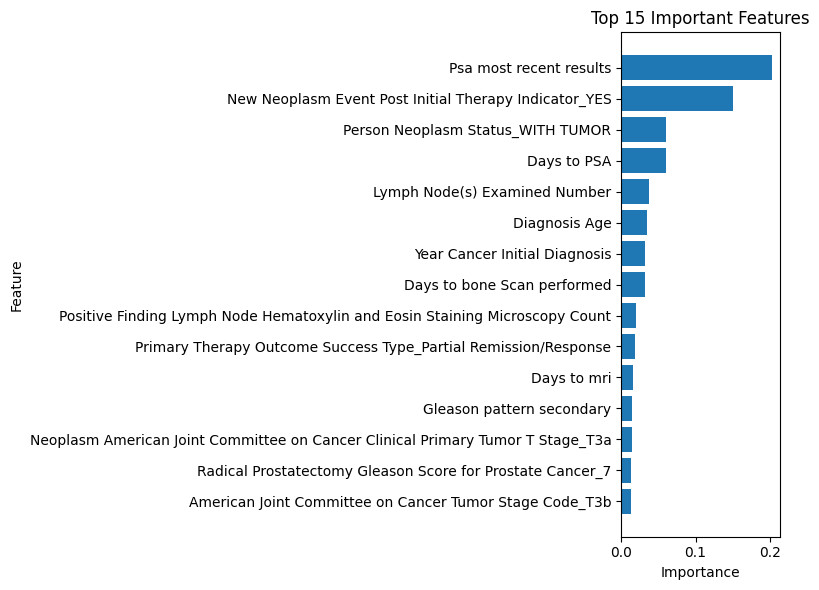

In [81]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.tight_layout()

plt.show()

In [82]:
print("Model Comparison")
print("=" * 50)

results

Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.873563,0.545455,0.500000,0.521739,0.887778
1,Random Forest,0.919540,1.000000,0.416667,0.588235,0.988889


In [83]:
best_model = results.loc[
    results["ROC-AUC"].idxmax()
]

print(
    "Best Model:",
    best_model["Model"]
)

print(
    "ROC-AUC:",
    round(best_model["ROC-AUC"], 3)
)

Best Model: Random Forest
ROC-AUC: 0.989
